In [9]:
# IMPORTS

import pandas as pd
import numpy as np
import pickle
import warnings
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from uncertainty_transformer import UncertaintyTransformer
from uncertainty_utils import EPS, N_BINS

print("Imports done.")

Imports done.


In [10]:
# LOAD MODEL + SPLIT INDICES

with open('best_model_finetuned.pkl', 'rb') as f:
    finetuned_model = pickle.load(f)

with open('model_metadata.pkl', 'rb') as f:
    model_metadata = pickle.load(f)

with open('split_indices.pkl', 'rb') as f:
    split_indices = pickle.load(f)

FEATURES   = sorted(model_metadata['features'])
LABEL_COL  = "GRUP"
train_idx  = pd.Index(split_indices['train_idx'])
test_idx   = pd.Index(split_indices['test_idx'])

print(f"Model      : {model_metadata['model_name']}")
print(f"Features   : {len(FEATURES)}")
print(f"Train idx  : {len(train_idx)} patients")
print(f"Test idx   : {len(test_idx)} patients")

Model      : VotingClassifier(LogisticRegression+SVC+RandomForestClassifier)
Features   : 45
Train idx  : 147 patients
Test idx   : 37 patients


In [11]:
# LOAD DATA — same NaN strategy as uncertainty.ipynb / finetuning.ipynb

NAN_COL_THRESHOLD = 0.20

df_raw = pd.read_excel("Miyokardit_08.12.xlsx")

# Keep model features + label + subgroup column
keep   = FEATURES + [LABEL_COL, 'TYPE of DIAGNOSIS']
df_all = df_raw[[c for c in keep if c in df_raw.columns]].copy()

# Standardise hidden NaN representations
JUNK = [" ", "", "-", "--", "nan", "NaN", "None",
        "#VALUE!", "#N/A", "#REF!", "#DIV/0!", "#NUM!", "#NAME?", "#NULL!"]
df_all = df_all.replace(JUNK, pd.NA)
for col in FEATURES:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all['TYPE of DIAGNOSIS'] = pd.to_numeric(df_all['TYPE of DIAGNOSIS'], errors='coerce').astype('Int64')

# Respect the original train/test split
df_train_all = df_all.loc[df_all.index.intersection(train_idx)].copy()
df_test_all  = df_all.loc[df_all.index.intersection(test_idx)].copy()

print(f"Total loaded : {len(df_all)} patients")
print(f"Train split  : {len(df_train_all)} patients")
print(f"Test split   : {len(df_test_all)} patients")
print(f"\nTYPE of DIAGNOSIS distribution (full):")
print(df_all['TYPE of DIAGNOSIS'].value_counts().sort_index().rename('n').to_frame())

Total loaded : 184 patients
Train split  : 147 patients
Test split   : 37 patients

TYPE of DIAGNOSIS distribution (full):
                     n
TYPE of DIAGNOSIS     
1                   45
2                   13
3                   25
4                  101


In [12]:
# SAMPLE SIZE OVERVIEW — train / test per TYPE

print(f"{'TYPE':<6} {'GRUP':<6} {'Train n':>8} {'Test n':>8} {'Total':>8}")
print("-" * 42)
for t in sorted(df_all['TYPE of DIAGNOSIS'].dropna().unique()):
    tr = df_train_all[df_train_all['TYPE of DIAGNOSIS'] == t]
    te = df_test_all [df_test_all ['TYPE of DIAGNOSIS'] == t]
    g  = int(df_all.loc[df_all['TYPE of DIAGNOSIS'] == t, LABEL_COL].dropna().iloc[0])
    print(f"  {int(t):<4} {g:<6} {len(tr):>8} {len(te):>8} {len(tr)+len(te):>8}")

print()
print(f"{'Comparison':<22} {'Train n':>8} {'Test n':>8} {'Total':>8}")
print("-" * 42)
for types, label in [([1,4],'Type 1 vs 4'), ([2,4],'Type 2 vs 4'),
                     ([3,4],'Type 3 vs 4'), ([2,3,4],'Type 2+3 vs 4')]:
    tr = df_train_all[df_train_all['TYPE of DIAGNOSIS'].isin(types)]
    te = df_test_all [df_test_all ['TYPE of DIAGNOSIS'].isin(types)]
    print(f"  {label:<20} {len(tr):>8} {len(te):>8} {len(tr)+len(te):>8}")

TYPE   GRUP    Train n   Test n    Total
------------------------------------------
  1    1            37        8       45
  2    1            11        2       13
  3    1            18        7       25
  4    2            81       20      101

Comparison              Train n   Test n    Total
------------------------------------------
  Type 1 vs 4               118       28      146
  Type 2 vs 4                92       22      114
  Type 3 vs 4                99       27      126
  Type 2+3 vs 4             110       29      139


In [13]:
# COMPARISON FUNCTION
# Mirrors uncertainty.ipynb / finetuning.ipynb strategy:
#   - CV on training patients of that subgroup only
#   - Final evaluation on held-out test patients of that subgroup
#   - STEP 1: drop columns with >20% NaN  |  STEP 2: drop rows with NaN

def preprocess(df_sub, feature_pool):
    """Apply column-then-row NaN strategy. Returns (X, y, surviving_features, dropped_cols)."""
    nan_pct      = df_sub[feature_pool].isna().mean()
    cols_to_drop = nan_pct[nan_pct > NAN_COL_THRESHOLD].index.tolist()
    surviving    = sorted([f for f in feature_pool if f not in cols_to_drop])
    df_sub       = df_sub.dropna(subset=surviving + [LABEL_COL])
    return df_sub[surviving], df_sub[LABEL_COL].values, surviving, cols_to_drop


def run_comparison(types, label):
    feature_pool = [f for f in FEATURES if f in df_all.columns]

    # ── Training subset ───────────────────────────────────────────────────
    tr = df_train_all[df_train_all['TYPE of DIAGNOSIS'].isin(types)].copy()
    X_train, y_train, surviving, dropped = preprocess(tr, feature_pool)

    n_tr_c1 = int((y_train == 1).sum())
    n_tr_c2 = int((y_train == 2).sum())
    n_splits = min(5, n_tr_c1, n_tr_c2)

    if dropped:
        print(f"\n  [!] Dropped columns (>{int(NAN_COL_THRESHOLD*100)}% NaN): {dropped}")

    # ── CV on training subset (same as main notebooks) ────────────────────
    clf = clone(finetuned_model.named_steps['clf'])
    pipeline = Pipeline([
        ("uncertainty", UncertaintyTransformer(
            feature_names=surviving, class_labels=None, n_bins=N_BINS, eps=EPS)),
        ("scaler", StandardScaler()),
        ("clf",   clf),
    ])

    cv     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_res = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring={'accuracy':'accuracy', 'precision_macro':'precision_macro',
                 'recall_macro':'recall_macro', 'f1_macro':'f1_macro'},
        return_train_score=False, n_jobs=-1,
    )

    def fmt(m): v = cv_res[f'test_{m}']; return f"{v.mean():.3f} ± {v.std():.3f}"

    # ── Test subset — held-out final evaluation ───────────────────────────
    te = df_test_all[df_test_all['TYPE of DIAGNOSIS'].isin(types)].copy()
    X_test, y_test, _, _ = preprocess(te, surviving)   # use same surviving features

    n_te_c1 = int((y_test == 1).sum())
    n_te_c2 = int((y_test == 2).sum())

    # Fit on full training subset, evaluate on test subset
    pipeline_final = Pipeline([
        ("uncertainty", UncertaintyTransformer(
            feature_names=surviving, class_labels=None, n_bins=N_BINS, eps=EPS)),
        ("scaler", StandardScaler()),
        ("clf",   clone(finetuned_model.named_steps['clf'])),
    ])
    pipeline_final.fit(X_train, y_train)
    y_pred = pipeline_final.predict(X_test)

    test_metrics = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_test, y_pred, average='macro', zero_division=0),
    }

    # ── Print ─────────────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    print(f"  Train : {len(X_train)} patients  (class 1: {n_tr_c1}, class 2: {n_tr_c2})  |  {n_splits}-fold CV  |  {len(surviving)} features")
    print(f"  Test  : {len(X_test)}  patients  (class 1: {n_te_c1}, class 2: {n_te_c2})")
    print(f"\n  --- CV results (train) ---")
    print(f"  Accuracy  : {fmt('accuracy')}")
    print(f"  Precision : {fmt('precision_macro')}")
    print(f"  Recall    : {fmt('recall_macro')}")
    print(f"  F1        : {fmt('f1_macro')}")
    print(f"\n  --- Held-out test results ---")
    for k, v in test_metrics.items():
        print(f"  {k.capitalize():<10}: {v:.3f}")

    return {
        'Comparison'      : label,
        # sizes
        'Train n'         : len(X_train),
        'Train class1'    : n_tr_c1,
        'Train class2'    : n_tr_c2,
        'Test n'          : len(X_test),
        'Test class1'     : n_te_c1,
        'Test class2'     : n_te_c2,
        'Features'        : len(surviving),
        'CV folds'        : n_splits,
        # CV
        'CV Accuracy'     : fmt('accuracy'),
        'CV Precision'    : fmt('precision_macro'),
        'CV Recall'       : fmt('recall_macro'),
        'CV F1'           : fmt('f1_macro'),
        # test
        'Test Accuracy'   : f"{test_metrics['accuracy']:.3f}",
        'Test Precision'  : f"{test_metrics['precision']:.3f}",
        'Test Recall'     : f"{test_metrics['recall']:.3f}",
        'Test F1'         : f"{test_metrics['f1']:.3f}",
        # raw for plotting
        '_cv_f1'          : cv_res['test_f1_macro'].mean(),
        '_cv_recall'      : cv_res['test_recall_macro'].mean(),
        '_test_f1'        : test_metrics['f1'],
        '_test_recall'    : test_metrics['recall'],
        '_test_acc'       : test_metrics['accuracy'],
        '_test_prec'      : test_metrics['precision'],
    }

In [14]:
# RUN ALL COMPARISONS

results = []
for types, label in [
    ([1, 4],    'Type 1 vs Type 4'),
    ([2, 4],    'Type 2 vs Type 4'),
    ([3, 4],    'Type 3 vs Type 4'),
    ([2, 3, 4], 'Type 2+3 vs Type 4'),
]:
    results.append(run_comparison(types, label))


  Type 1 vs Type 4
  Train : 104 patients  (class 1: 25, class 2: 79)  |  5-fold CV  |  45 features
  Test  : 24  patients  (class 1: 6, class 2: 18)

  --- CV results (train) ---
  Accuracy  : 0.952 ± 0.001
  Precision : 0.949 ± 0.026
  Recall    : 0.927 ± 0.034
  F1        : 0.933 ± 0.005

  --- Held-out test results ---
  Accuracy  : 0.875
  Precision : 0.929
  Recall    : 0.750
  F1        : 0.795

  Type 2 vs Type 4
  Train : 88 patients  (class 1: 9, class 2: 79)  |  5-fold CV  |  45 features
  Test  : 20  patients  (class 1: 2, class 2: 18)

  --- CV results (train) ---
  Accuracy  : 0.967 ± 0.027
  Precision : 0.927 ± 0.078
  Recall    : 0.938 ± 0.095
  F1        : 0.917 ± 0.072

  --- Held-out test results ---
  Accuracy  : 0.950
  Precision : 0.974
  Recall    : 0.750
  F1        : 0.820

  Type 3 vs Type 4
  Train : 94 patients  (class 1: 15, class 2: 79)  |  5-fold CV  |  45 features
  Test  : 24  patients  (class 1: 6, class 2: 18)

  --- CV results (train) ---
  Accuracy

In [15]:
# SUMMARY TABLE

df_summary = pd.DataFrame(results)

# Sample sizes
size_cols = ['Comparison', 'Train n', 'Train class1', 'Train class2',
             'Test n', 'Test class1', 'Test class2', 'Features', 'CV folds']
print("SAMPLE SIZES")
print("="*80)
display(df_summary[size_cols].set_index('Comparison'))

# CV results
cv_cols = ['Comparison', 'CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']
print("\nCV RESULTS  (mean ± std, training patients only)")
print("="*80)
display(df_summary[cv_cols].set_index('Comparison'))

# Test results
test_cols = ['Comparison', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
print("\nHELD-OUT TEST RESULTS  (never seen during training)")
print("="*80)
display(df_summary[test_cols].set_index('Comparison'))

SAMPLE SIZES


,Train n,Train class1,Train class2,Test n,Test class1,Test class2,Features,CV folds
Comparison,,,,,,,,
Type 1 vs Type 4,104,25,79,24,6,18,45,5
Type 2 vs Type 4,88,9,79,20,2,18,45,5
Type 3 vs Type 4,94,15,79,24,6,18,45,5
Type 2+3 vs Type 4,103,24,79,26,8,18,45,5



CV RESULTS  (mean ± std, training patients only)


,CV Accuracy,CV Precision,CV Recall,CV F1
Comparison,,,,
Type 1 vs Type 4,0.952 ± 0.001,0.949 ± 0.026,0.927 ± 0.034,0.933 ± 0.005
Type 2 vs Type 4,0.967 ± 0.027,0.927 ± 0.078,0.938 ± 0.095,0.917 ± 0.072
Type 3 vs Type 4,0.968 ± 0.042,0.954 ± 0.077,0.927 ± 0.090,0.937 ± 0.081
Type 2+3 vs Type 4,0.970 ± 0.040,0.972 ± 0.036,0.954 ± 0.078,0.956 ± 0.061



HELD-OUT TEST RESULTS  (never seen during training)


,Test Accuracy,Test Precision,Test Recall,Test F1
Comparison,,,,
Type 1 vs Type 4,0.875,0.929,0.750,0.795
Type 2 vs Type 4,0.950,0.974,0.750,0.820
Type 3 vs Type 4,0.917,0.950,0.833,0.874
Type 2+3 vs Type 4,0.885,0.929,0.812,0.846


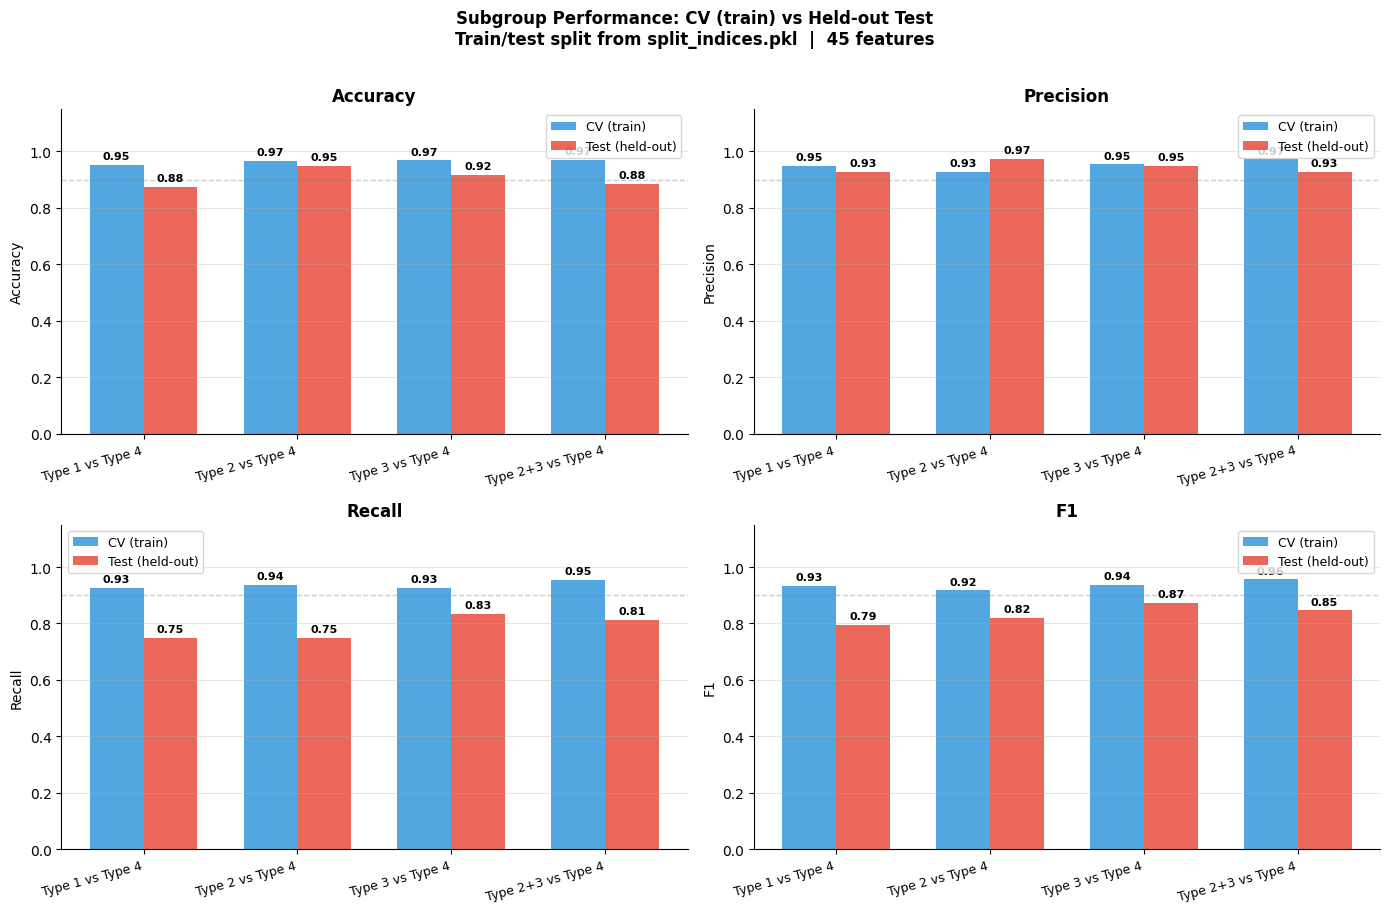

Saved: subgroup_comparison.pdf


In [16]:
# VISUALISATION — CV vs Test metrics side by side

comparisons = [r['Comparison'] for r in results]

# Parse CV metric means from stored strings (e.g. "0.812 ± 0.034")
def parse_mean(s): return float(s.split(' ')[0])

for r in results:
    r['_cv_acc']  = parse_mean(r['CV Accuracy'])
    r['_cv_prec'] = parse_mean(r['CV Precision'])

metrics = {
    'Accuracy' : ('_cv_acc',    '_test_acc'),
    'Precision': ('_cv_prec',   '_test_prec'),
    'Recall'   : ('_cv_recall', '_test_recall'),
    'F1'       : ('_cv_f1',     '_test_f1'),
}

x = np.arange(len(comparisons))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, (metric_name, (cv_key, test_key)) in zip(axes, metrics.items()):
    cv_vals   = [r[cv_key]   for r in results]
    test_vals = [r[test_key] for r in results]

    bars_cv   = ax.bar(x - width/2, cv_vals,   width, label='CV (train)',       color='#3498DB', alpha=0.85)
    bars_test = ax.bar(x + width/2, test_vals, width, label='Test (held-out)',  color='#E74C3C', alpha=0.85)

    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels(comparisons, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=10)
    ax.axhline(0.9, color='grey', linestyle='--', alpha=0.4, linewidth=1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, val in list(zip(bars_cv, cv_vals)) + list(zip(bars_test, test_vals)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.013,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Subgroup Performance: CV (train) vs Held-out Test\n'
             f'Train/test split from split_indices.pkl  |  {len(FEATURES)} features',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('subgroup_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: subgroup_comparison.pdf")